<a href="https://colab.research.google.com/github/itz-mehraz/bengali-social-media-scam-detection/blob/main/notebooks/social_media_scam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello Mehraz")


Hello Mehraz


In [ ]:
import pandas as pd

data = pd.read_csv("fake_job_postings.csv")

data.head()


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
data.shape


(17880, 18)

In [ ]:
data.columns


Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [ ]:
data["text"] = data["title"].fillna("") + " " + \
               data["description"].fillna("") + " " + \
               data["requirements"].fillna("") + " " + \
               data["company_profile"].fillna("") + " " + \
               data["benefits"].fillna("")

data[["text","fraudulent"]].head()


,text,fraudulent
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(data["text"])

y = data["fraudulent"]

X.shape


(17880, 5000)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((14304, 5000), (3576, 5000))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

accuracy


0.9723154362416108

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))

confusion_matrix(y_test, predictions)


              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3395
           1       1.00      0.45      0.62       181

    accuracy                           0.97      3576
   macro avg       0.99      0.73      0.80      3576
weighted avg       0.97      0.97      0.97      3576



array([[3395,    0],
       [  99,   82]])

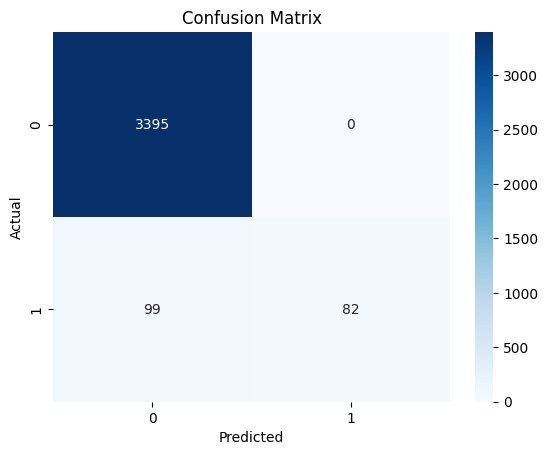

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import pickle

pickle.dump(model, open("job_scam_model.pkl", "wb"))


In [ ]:
def predict_job_post(text):
    text_tfidf = tfidf.transform([text])
    prediction = model.predict(text_tfidf)

    if prediction[0] == 1:
        return "Fake Job Scam"
    else:
        return "Real Job"

# Example test
predict_job_post("Earn 5000 USD per week from home. No experience needed. Inbox now.")


'Fake Job Scam'

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

fb_data = pd.read_csv("bd_synthetic_fb_pilot_dataset.csv")

fb_data["predicted_label"] = model.predict(tfidf.transform(fb_data["text"]))
fb_data["predicted_class"] = fb_data["predicted_label"].map({
    1: "Fake Job Scam",
    0: "Real Job"
})

print("Facebook/Test Dataset Accuracy:", accuracy_score(fb_data["label"], fb_data["predicted_label"]))
print("\nClassification Report:\n")
print(classification_report(fb_data["label"], fb_data["predicted_label"]))

fb_data[["text", "label", "predicted_label", "predicted_class"]].head(10)


Facebook/Test Dataset Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       100
           1       0.00      0.00      0.00       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,text,label,predicted_label,predicted_class
0,ঘরে বসে income! no experience needed. weekly p...,1,0,Real Job
1,North Valley School job circular for Data Entr...,0,0,Real Job
2,Daily earning offer — high earning with small ...,1,0,Real Job
3,North Valley School is hiring a Digital Market...,0,0,Real Job
4,Daily earning offer for Bangladesh audience. n...,1,0,Real Job
5,Skyline Logistics is hiring a Data Entry Opera...,0,0,Real Job
6,Part time job alert for Bangladesh audience. p...,1,0,Real Job
7,DeltaSoft job circular for Customer Support Ex...,0,0,Real Job
8,ঘরে বসে income! passport/CV chara start. month...,1,0,Real Job
9,We are looking for a HR Intern at DeltaSoft. i...,0,0,Real Job


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# combine EMSCAD + Facebook dataset
combined_data = pd.concat([
    data[["text", "fraudulent"]].rename(columns={"fraudulent": "label"}),
    fb_data[["text", "label"]]
], ignore_index=True)

# create better TF-IDF for mixed text
tfidf2 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2)
)

X2 = tfidf2.fit_transform(combined_data["text"])
y2 = combined_data["label"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

model2 = LogisticRegression(max_iter=2000, class_weight="balanced")
model2.fit(X2_train, y2_train)

pred2 = model2.predict(X2_test)

print("New Accuracy:", accuracy_score(y2_test, pred2))
print("\nClassification Report:\n")
print(classification_report(y2_test, pred2))


New Accuracy: 0.9706858407079646

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3423
           1       0.67      0.88      0.76       193

    accuracy                           0.97      3616
   macro avg       0.83      0.93      0.87      3616
weighted avg       0.98      0.97      0.97      3616



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split Facebook data separately
fb_train, fb_test = train_test_split(
    fb_data,
    test_size=0.2,
    random_state=42,
    stratify=fb_data["label"]
)

# Use EMSCAD + Facebook-train only
train_mix = pd.concat([
    data[["text", "fraudulent"]].rename(columns={"fraudulent": "label"}),
    fb_train[["text", "label"]]
], ignore_index=True)

# Vectorize
tfidf3 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)
)

X3_train = tfidf3.fit_transform(train_mix["text"])
y3_train = train_mix["label"]

X3_test_fb = tfidf3.transform(fb_test["text"])
y3_test_fb = fb_test["label"]

# Train model
model3 = LogisticRegression(max_iter=2000, class_weight="balanced")
model3.fit(X3_train, y3_train)

# Predict on unseen Facebook-only test set
fb_pred = model3.predict(X3_test_fb)

print("Facebook-only Test Accuracy:", accuracy_score(y3_test_fb, fb_pred))
print("\nFacebook-only Classification Report:\n")
print(classification_report(y3_test_fb, fb_pred))

fb_test = fb_test.copy()
fb_test["predicted_label"] = fb_pred
fb_test["predicted_class"] = fb_test["predicted_label"].map({
    1: "Fake Job Scam",
    0: "Real Job"
})

fb_test[["text", "label", "predicted_label", "predicted_class"]].head(10)


Facebook-only Test Accuracy: 0.875

Facebook-only Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.75      0.86        20
           1       0.80      1.00      0.89        20

    accuracy                           0.88        40
   macro avg       0.90      0.88      0.87        40
weighted avg       0.90      0.88      0.87        40



,text,label,predicted_label,predicted_class
75,We are looking for a Digital Marketing Executi...,0,0,Real Job
80,Easy task job. weekend eo korte parben. Telegr...,1,1,Fake Job Scam
190,"Easy task job — weekly payout promise, passpor...",1,1,Fake Job Scam
192,Online job available! mobile diye korte parben...,1,1,Fake Job Scam
47,We are looking for a Office Admin at North Val...,0,1,Fake Job Scam
8,ঘরে বসে income! passport/CV chara start. month...,1,1,Fake Job Scam
59,We are looking for a HR Intern at Dhaka Tech S...,0,0,Real Job
160,নতুন vacancy. training not required. comment i...,1,1,Fake Job Scam
122,Online job available. student/housewife anyone...,1,1,Fake Job Scam
173,North Valley School job circular for HR Intern...,0,0,Real Job


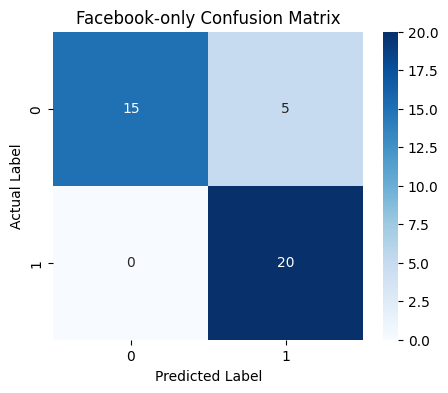

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_fb = confusion_matrix(y3_test_fb, fb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_fb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Facebook-only Confusion Matrix")
plt.show()


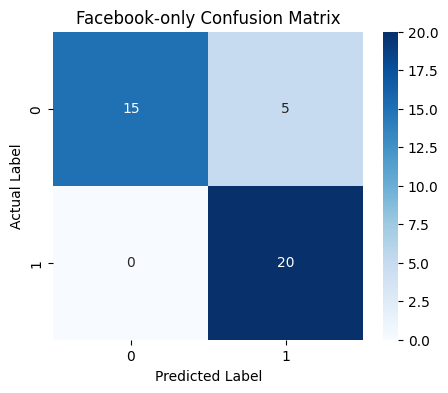

In [ ]:
fb_test.to_csv("facebook_test_results.csv", index=False)

plt.figure(figsize=(5,4))
sns.heatmap(cm_fb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Facebook-only Confusion Matrix")
plt.savefig("facebook_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


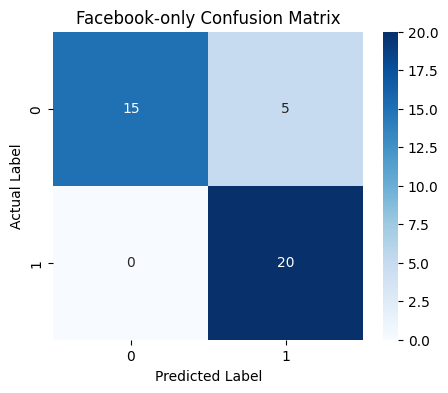

In [ ]:
fb_test.to_csv("facebook_test_results.csv", index=False)

plt.figure(figsize=(5,4))
sns.heatmap(cm_fb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Facebook-only Confusion Matrix")
plt.savefig("facebook_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

data = pd.read_csv("/fake_job_postings.csv")

data["text"] = data["title"].fillna("") + " " + \
               data["description"].fillna("") + " " + \
               data["requirements"].fillna("") + " " + \
               data["company_profile"].fillna("") + " " + \
               data["benefits"].fillna("")

fb_data = pd.read_csv("/bd_synthetic_fb_pilot_dataset.csv")

fb_train, fb_test = train_test_split(
    fb_data,
    test_size=0.2,
    random_state=42,
    stratify=fb_data["label"]
)

train_mix = pd.concat([
    data[["text", "fraudulent"]].rename(columns={"fraudulent": "label"}),
    fb_train[["text", "label"]]
], ignore_index=True)

tfidf3 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)
)

X3_train = tfidf3.fit_transform(train_mix["text"])
y3_train = train_mix["label"]

X3_test_fb = tfidf3.transform(fb_test["text"])
y3_test_fb = fb_test["label"]

print("Recovery done")


Recovery done


In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = LinearSVC(class_weight="balanced", max_iter=5000)
svm_model.fit(X3_train, y3_train)

svm_pred = svm_model.predict(X3_test_fb)

print("SVM Facebook-only Test Accuracy:", accuracy_score(y3_test_fb, svm_pred))
print("\nSVM Classification Report:\n")
print(classification_report(y3_test_fb, svm_pred))

cm_svm = confusion_matrix(y3_test_fb, svm_pred)
cm_svm


SVM Facebook-only Test Accuracy: 0.95

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.91      1.00      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



array([[18,  2],
       [ 0, 20]])

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X3_train, y3_train)

rf_pred = rf_model.predict(X3_test_fb)

print("Random Forest Facebook-only Test Accuracy:", accuracy_score(y3_test_fb, rf_pred))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y3_test_fb, rf_pred))

cm_rf = confusion_matrix(y3_test_fb, rf_pred)
cm_rf


Random Forest Facebook-only Test Accuracy: 1.0

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



array([[20,  0],
       [ 0, 20]])

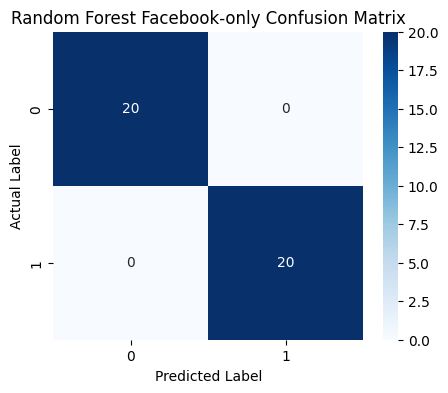

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Facebook-only Confusion Matrix")
plt.show()


In [17]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Train an explainable logistic regression model on the same train data
logit_model = LogisticRegression(max_iter=2000, class_weight="balanced")
logit_model.fit(X3_train, y3_train)

# Get feature names and coefficients
feature_names = tfidf3.get_feature_names_out()
coefficients = logit_model.coef_[0]

# Top scam-indicating words
top_scam_idx = coefficients.argsort()[-20:][::-1]
top_real_idx = coefficients.argsort()[:20]

top_scam_words = pd.DataFrame({
    "word": feature_names[top_scam_idx],
    "weight": coefficients[top_scam_idx]
})

top_real_words = pd.DataFrame({
    "word": feature_names[top_real_idx],
    "weight": coefficients[top_real_idx]
})

print("Top scam-indicating words:")
print(top_scam_words)

print("\nTop real-job-indicating words:")
print(top_real_words)


Top scam-indicating words:
              word    weight
0             link  5.132903
1             earn  3.749866
2      engineering  3.663969
3            below  3.554792
4         offshore  3.415429
5       data entry  3.281625
6         aptitude  3.246686
7              000  3.047838
8            money  2.931613
9   administrative  2.912994
10           clerk  2.875554
11       assistant  2.831511
12          income  2.827785
13         oil and  2.817782
14      accountant  2.718386
15     high school  2.584456
16  candidates are  2.457777
17            cash  2.446832
18             per  2.425425
19         earning  2.424122

Top real-job-indicating words:
           word    weight
0           our -4.464190
1       digital -3.206051
2     companies -2.975739
3   recruitment -2.785158
4       english -2.723074
5            of -2.679409
6            in -2.657819
7     marketing -2.631499
8            it -2.620002
9           web -2.501292
10           is -2.482699
11           by -2.4

In [18]:
import pandas as pd
import numpy as np

def explain_post(text, top_n=10):
    vec = tfidf3.transform([text])
    pred = logit_model.predict(vec)[0]
    prob_scam = logit_model.predict_proba(vec)[0][1]

    feature_names = tfidf3.get_feature_names_out()
    coefs = logit_model.coef_[0]
    row = vec.toarray()[0]

    nz_idx = np.where(row != 0)[0]

    contributions = []
    for idx in nz_idx:
        contribution = row[idx] * coefs[idx]
        contributions.append((feature_names[idx], contribution))

    suspicious = sorted(
        [x for x in contributions if x[1] > 0],
        key=lambda x: x[1],
        reverse=True
    )[:top_n]

    real_signals = sorted(
        [x for x in contributions if x[1] < 0],
        key=lambda x: x[1]
    )[:top_n]

    result = "Fake Job Scam" if pred == 1 else "Real Job"

    print("Prediction:", result)
    print("Scam Risk Score:", round(prob_scam * 100, 2), "%")

    print("\nTop suspicious words/signals:")
    if suspicious:
        for word, score in suspicious:
            print(f"- {word}: {score:.4f}")
    else:
        print("- None")

    print("\nTop real-job signals:")
    if real_signals:
        for word, score in real_signals:
            print(f"- {word}: {score:.4f}")
    else:
        print("- None")


In [19]:
sample_text = "Earn money from home. No experience needed. Inbox now. Weekly payment. bkash available."
explain_post(sample_text)


Prediction: Fake Job Scam
Scam Risk Score: 99.34 %

Top suspicious words/signals:
- earn: 1.4526
- money: 1.0036
- from home: 0.6232
- payment: 0.5442
- no: 0.5029
- needed: 0.3229
- home: 0.2368
- weekly: 0.2010
- from: 0.1720
- available: 0.0558

Top real-job signals:
- now: -0.1304
- experience: -0.0866
